In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"The notebook is running on : {device} device.")

The notebook is running on : cuda device.


In [4]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 514kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [16]:
class ClassConditionedUnet(nn.Module):
    def __init__(self,num_classes=10,class_emb_size=4):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_classes,class_emb_size)
        
        self.model = UNet2DModel(
        sample_size=28,           
        in_channels=1 + class_emb_size, 
        out_channels=1,           
        layers_per_block=2,       
        block_out_channels=(32, 64, 64), 
        down_block_types=( 
            "DownBlock2D",        
            "AttnDownBlock2D",    
            "AttnDownBlock2D",
        ), 
        up_block_types=(
            "AttnUpBlock2D", 
            "AttnUpBlock2D",      
            "UpBlock2D",
        ),) 
    def forward(self,x,t,class_labels):
        batch_size,channels,width,height = x.shape
        class_conditions = self.embedding_layer(class_labels)
        class_conditions = class_conditions.view(batch_size,class_conditions.shape[1],1,1).expand(batch_size,class_conditions.shape[1],width,height)

        net_input = torch.cat((x,class_conditions),1)
        return self.model(net_input,t).sample

In [17]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000,beta_schedule='squaredcos_cap_v2')

Finished epoch 0. Average of the last 100 loss values: 0.063238
Finished epoch 1. Average of the last 100 loss values: 0.045409
Finished epoch 2. Average of the last 100 loss values: 0.039324
Finished epoch 3. Average of the last 100 loss values: 0.036577
Finished epoch 4. Average of the last 100 loss values: 0.034169
Finished epoch 5. Average of the last 100 loss values: 0.032441
Finished epoch 6. Average of the last 100 loss values: 0.031564
Finished epoch 7. Average of the last 100 loss values: 0.031412
Finished epoch 8. Average of the last 100 loss values: 0.030540
Finished epoch 9. Average of the last 100 loss values: 0.029846


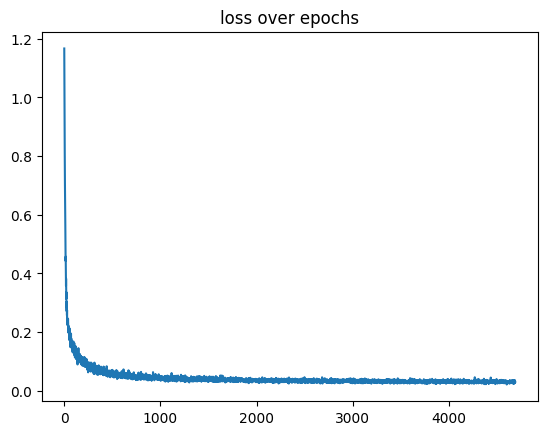

In [18]:
train_loader = DataLoader(
    dataset,
    batch_size = 128,
    shuffle = True,
)

Epochs = 10 
Model = ClassConditionedUnet().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(Model.parameters(),lr=0.0001)
losses = []

for epoch in range(Epochs):
    for x,y in train_loader:
        x = x.to(device)
        y = y.to(device)
        noise = torch.randn_like(x)
        timesteps = torch.randint(0,999,(x.shape[0],)).long().to(device)
        noisy_x = noise_scheduler.add_noise(x,noise,timesteps)
        pred = Model(noisy_x,timesteps,y)
        loss = loss_fn(pred,noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    avg_loss = sum(losses[-100:])/100
    print(f'Finished epoch {epoch}. Average of the last 100 loss values: {avg_loss:05f}')
plt.plot(losses)
plt.title('loss over epochs')
plt.show()

 7


0it [00:00, ?it/s]

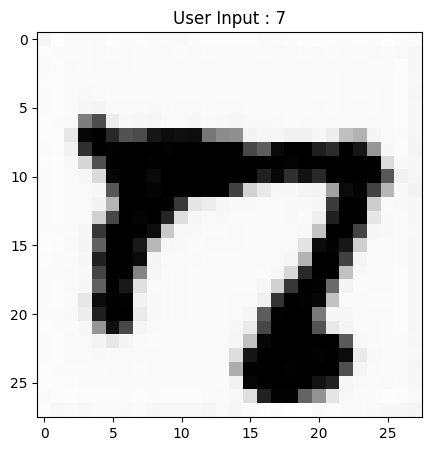

In [20]:
x = torch.randn(1, 1, 28, 28).to(device)
inp = int(input())
y = torch.tensor([inp]).flatten().to(device)

for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    with torch.no_grad():
        residual = Model(x, t, y) 
    x = noise_scheduler.step(residual, t, x).prev_sample

plt.figure(figsize=(5, 5))
plt.imshow(torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1))[0], cmap='Greys')
plt.title(f"User Input : {inp}")
plt.show()